In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:/Users/DHANUSH/OneDrive/Desktop/isme/T4/Foundation of ML/clustering/Nutrient_Composition_Dataset.csv")

In [3]:
df.head()

,S.No,Protein,Fat,vitaminC,Fibre,Product
0,1,0.452369,1.170926,1.079271,1.702960,"Amaranth leaves, cooked, boiled, drained, with..."
1,2,2.321087,0.706856,0.350088,0.658249,Bacon and beef sticks
2,3,0.884554,1.186571,2.428544,1.984562,"Apples, frozen, unsweetened, unheated (Include..."
3,4,0.715501,0.577599,0.270925,0.369266,"Alcoholic beverage, beer, light, BUD LIGHT"
4,5,0.132610,0.544521,0.116884,0.557309,"Alcoholic beverage, daiquiri, canned"


In [4]:
df.tail()

,S.No,Protein,Fat,vitaminC,Fibre,Product
1741,1742,1.188371,1.963861,1.144457,1.438795,Unknown
1742,1743,2.325762,1.970995,1.352002,0.051109,Unknown
1743,1744,0.597130,0.727934,1.031587,0.255496,Unknown
1744,1745,0.748026,1.722406,1.319929,0.920391,Unknown
1745,1746,2.013799,0.576179,0.515998,1.536694,Unknown


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1746 entries, 0 to 1745
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.No      1746 non-null   int64  
 1   Protein   1746 non-null   float64
 2   Fat       1746 non-null   float64
 3   vitaminC  1746 non-null   float64
 4   Fibre     1746 non-null   float64
 5   Product   1746 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 82.0+ KB


In [6]:
df.describe()

,S.No,Protein,Fat,vitaminC,Fibre
count,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000
mean,873.500000,0.922470,0.900091,0.900146,0.900830
std,504.171102,0.627128,0.634617,0.623847,0.626875
min,1.000000,0.000128,0.000267,0.000029,0.002579
25%,437.250000,0.435853,0.394784,0.419103,0.389124
50%,873.500000,0.813025,0.804687,0.796290,0.820783
75%,1309.750000,1.295106,1.298988,1.280870,1.295732
max,1746.000000,4.016890,3.979364,4.013322,3.570331


In [9]:
df.count()

S.No        1746
Protein     1746
Fat         1746
vitaminC    1746
Fibre       1746
Product     1746
dtype: int64

In [17]:
df.isnull().sum()

S.No        0
Protein     0
Fat         0
vitaminC    0
Fibre       0
Product     0
dtype: int64

In [22]:
df1=df.drop(['S.No','Product'],axis=1)

In [25]:
df1.head()

,Protein,Fat,vitaminC,Fibre
0,0.452369,1.170926,1.079271,1.702960
1,2.321087,0.706856,0.350088,0.658249
2,0.884554,1.186571,2.428544,1.984562
3,0.715501,0.577599,0.270925,0.369266
4,0.132610,0.544521,0.116884,0.557309


In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [29]:
wardlink=linkage(df1,method='ward')

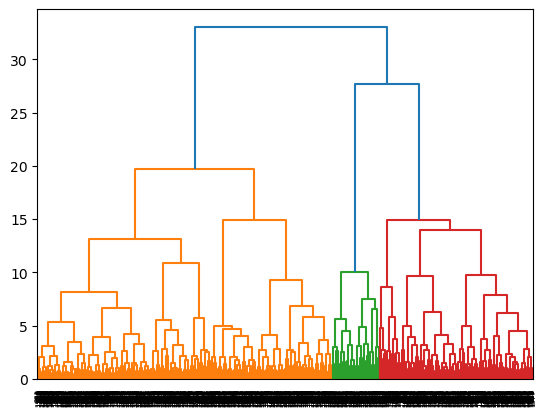

In [31]:
dend=dendrogram(wardlink)

1st Method - cluster method

In [34]:
from scipy.cluster.hierarchy import fcluster
cluster1=fcluster(wardlink,3,criterion='maxclust')
cluster1

array([1, 1, 2, ..., 1, 1, 3], shape=(1746,), dtype=int32)

2nd Method - distance method

In [38]:
cluster2= fcluster(wardlink,23,criterion='distance')
cluster2

array([1, 1, 2, ..., 1, 1, 3], shape=(1746,), dtype=int32)

In [40]:
df1['added_cluster']=cluster1

In [41]:
df1.head()

,Protein,Fat,vitaminC,Fibre,added_cluster
0,0.452369,1.170926,1.079271,1.702960,1
1,2.321087,0.706856,0.350088,0.658249,1
2,0.884554,1.186571,2.428544,1.984562,2
3,0.715501,0.577599,0.270925,0.369266,1
4,0.132610,0.544521,0.116884,0.557309,1


In [43]:
df1.groupby('added_cluster').count()

,Protein,Fat,vitaminC,Fibre
added_cluster,,,,
1,1040,1040,1040,1040
2,164,164,164,164
3,542,542,542,542


In [44]:
df1.groupby('added_cluster').mean()

,Protein,Fat,vitaminC,Fibre
added_cluster,,,,
1,0.655279,0.574868,0.792455,0.747145
2,1.010078,0.817892,2.038615,1.774143
3,1.408652,1.549007,0.762304,0.931472


In [45]:
df1.to_csv('C:/Users/DHANUSH/OneDrive/Desktop/isme/T4/Foundation of ML/clustering/updated_nutrient_composition.csv')

In [48]:
df['added_cluster']=cluster1

In [49]:
df.head()

,S.No,Protein,Fat,vitaminC,Fibre,Product,added_cluster
0,1,0.452369,1.170926,1.079271,1.702960,"Amaranth leaves, cooked, boiled, drained, with...",1
1,2,2.321087,0.706856,0.350088,0.658249,Bacon and beef sticks,1
2,3,0.884554,1.186571,2.428544,1.984562,"Apples, frozen, unsweetened, unheated (Include...",2
3,4,0.715501,0.577599,0.270925,0.369266,"Alcoholic beverage, beer, light, BUD LIGHT",1
4,5,0.132610,0.544521,0.116884,0.557309,"Alcoholic beverage, daiquiri, canned",1


In [51]:
df.to_csv('C:/Users/DHANUSH/OneDrive/Desktop/isme/T4/Foundation of ML/clustering/updated_nutrient_composition.csv')